# gym_env_explainer_bluesky.ipynb

This notebook draws a direct parallel between:

- **`TinyApproachEnv`** — pure numpy, runs anywhere, instant, deterministic
- **`ApproachCREnv2D`** — BlueSky flight simulator, realistic physics, lat/lon, A320 performance model

Every section shows the **same concept** implemented in both, so you can see exactly what BlueSky adds and what it costs.


In [32]:
import numpy as np
import gymnasium as gym
from gymnasium import spaces
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from IPython.display import display, clear_output
import ipywidgets as widgets


## 1. Physics Engine

| | TinyApproachEnv | ApproachCREnv2D (BlueSky) |
|---|---|---|
| Engine | Pure numpy Euler integration | BlueSky full flight sim |
| Time step | 1 step = 1 discrete move | 1 agent step = 10 sim ticks × DT=5s = **50 real seconds** |
| Units | km, arbitrary speed | **NM, knots** — real aviation units |
| Aircraft model | Point mass, **instant** heading/speed change | A320 performance model — realistic turn radius, speed envelope |
| World geometry | Flat 100×100 km grid | **Spherical earth**, lat/lon via `kwikqdrdist` |
| Spawn | Fixed positions or presets | **Random** every episode within ±45° approach cone, 30–50 NM from fix |

### Numpy: Euler step
```python
rad = np.deg2rad(self.ownship_hdg)
self.ownship_pos += self.ownship_spd * np.array([np.sin(rad), np.cos(rad)])
```

### BlueSky: issues HDG/SPD commands, sim does the physics
```python
bs.stack.stack(f"HDG KL001 {new_hdg}")
bs.stack.stack(f"SPD KL001 {new_spd}")
for _ in range(ACTION_FREQUENCY):   # 10 ticks
    bs.sim.step()
```
BlueSky internally applies turn rate limits, acceleration curves, and atmosphere — the aircraft **cannot** change heading instantly.


## 2. Observation Space — what the agent sees

Both envs expose the same keys. The differences are in **how each value is computed and normalised**.


In [33]:
# Print the observation space keys and shapes for TinyApproachEnv
# (ApproachCREnv2D has the same keys minus proximity_warning)

NUM_INTRUDERS = 3
NUM_WAYPOINTS = 1

obs_space_numpy = spaces.Dict({
    "intruder_distance":    spaces.Box(-np.inf, np.inf, shape=(NUM_INTRUDERS,), dtype=np.float64),
    "cos_bearing":          spaces.Box(-np.inf, np.inf, shape=(NUM_INTRUDERS,), dtype=np.float64),
    "sin_bearing":          spaces.Box(-np.inf, np.inf, shape=(NUM_INTRUDERS,), dtype=np.float64),
    "x_difference_speed":   spaces.Box(-np.inf, np.inf, shape=(NUM_INTRUDERS,), dtype=np.float64),
    "y_difference_speed":   spaces.Box(-np.inf, np.inf, shape=(NUM_INTRUDERS,), dtype=np.float64),
    "proximity_warning":    spaces.Box(-np.inf, np.inf, shape=(NUM_INTRUDERS,), dtype=np.float64),  # numpy only
    "waypoint_distance":    spaces.Box(-np.inf, np.inf, shape=(NUM_WAYPOINTS,), dtype=np.float64),
    "cos_drift":            spaces.Box(-np.inf, np.inf, shape=(NUM_WAYPOINTS,), dtype=np.float64),
    "sin_drift":            spaces.Box(-np.inf, np.inf, shape=(NUM_WAYPOINTS,), dtype=np.float64),
    "ownship_speed":        spaces.Box(-np.inf, np.inf, shape=(1,),             dtype=np.float64),
})

print("Key                   shape   numpy normaliser              bluesky normaliser")
print("-" * 80)
rows = [
    ("intruder_distance",  "(3,)", "dist / world_size (100 km)",  "dist_NM * NM2KM / (APPROACH_DISTANCE_MAX * NM2KM)"),
    ("cos/sin_bearing",    "(3,)", "arctan2 relative to hdg",     "kwikqdrdist qdr, bound ±180"),
    ("x_difference_speed", "(3,)", "rel_vel_x / world_size",      "-cos(hdg_diff) * int_spd / AC_SPD_MAX"),
    ("y_difference_speed", "(3,)", "rel_vel_y / world_size",      "own_spd - sin(hdg_diff)*int_spd / AC_SPD_MAX"),
    ("proximity_warning",  "(3,)", "1.0 if dist < 2x intr_r",    "NOT PRESENT in BlueSky env"),
    ("waypoint_distance",  "(1,)", "dist / world_size",           "wpt_dis_NM * NM2KM / (APPROACH_DISTANCE_MAX * NM2KM)"),
    ("cos/sin_drift",      "(1,)", "arctan2 to fix - hdg",        "kwikqdrdist to fix, bound ±180"),
    ("ownship_speed",      "(1,)", "spd / 8.0 (km/step)",         "gs / AC_SPD_MAX (230 kt)"),
]
for key, shape, numpy_n, bs_n in rows:
    print(f"{key:<22} {shape:<7} {numpy_n:<35} {bs_n}")


Key                   shape   numpy normaliser              bluesky normaliser
--------------------------------------------------------------------------------
intruder_distance      (3,)    dist / world_size (100 km)          dist_NM * NM2KM / (APPROACH_DISTANCE_MAX * NM2KM)
cos/sin_bearing        (3,)    arctan2 relative to hdg             kwikqdrdist qdr, bound ±180
x_difference_speed     (3,)    rel_vel_x / world_size              -cos(hdg_diff) * int_spd / AC_SPD_MAX
y_difference_speed     (3,)    rel_vel_y / world_size              own_spd - sin(hdg_diff)*int_spd / AC_SPD_MAX
proximity_warning      (3,)    1.0 if dist < 2x intr_r             NOT PRESENT in BlueSky env
waypoint_distance      (1,)    dist / world_size                   wpt_dis_NM * NM2KM / (APPROACH_DISTANCE_MAX * NM2KM)
cos/sin_drift          (1,)    arctan2 to fix - hdg                kwikqdrdist to fix, bound ±180
ownship_speed          (1,)    spd / 8.0 (km/step)                 gs / AC_SPD_MAX (230 kt)


## 3. Reward Function — what the agent is optimising

This is where the two envs differ most significantly.


In [34]:
reward_table = [
    ("Reach fix",        "+10.0  terminal",          "+1.0   non-terminal",
     "Numpy ends episode on fix. BlueSky continues to next waypoint (supports multi-waypoint routes)."),
    ("Intrusion",        "-10.0  TERMINAL",          "-1.0   non-terminal per step",
     "Numpy: collision = game over, strong signal. BlueSky: agent can fly through and recover — softer signal."),
    ("Progress (dense)", "+0.1 x delta_dist",        "NONE",
     "Numpy adds a shaping reward every step for closing distance. BlueSky relies on drift penalty alone."),
    ("Proximity ramp",   "-0.5 ramp inside 2x zone", "NONE",
     "Numpy warns the agent before the hard boundary. BlueSky has no warning zone."),
    ("Drift penalty",    "-0.001 x drift_deg",       "-0.1 x drift_rad",
     "BlueSky drift penalty is ~57x stronger per radian — heavily penalises heading deviation."),
    ("Speed deviation",  "NONE",                     "-0.05 x |dv/v_max|",
     "BlueSky penalises straying from 180 kt nominal. Numpy has no speed penalty."),
]

print(f"{'Component':<20} {'Numpy':<30} {'BlueSky':<30} Note")
print("-" * 120)
for comp, numpy_r, bs_r, note in reward_table:
    print(f"{comp:<20} {numpy_r:<30} {bs_r:<30} {note}")


Component            Numpy                          BlueSky                        Note
------------------------------------------------------------------------------------------------------------------------
Reach fix            +10.0  terminal                +1.0   non-terminal            Numpy ends episode on fix. BlueSky continues to next waypoint (supports multi-waypoint routes).
Intrusion            -10.0  TERMINAL                -1.0   non-terminal per step   Numpy: collision = game over, strong signal. BlueSky: agent can fly through and recover — softer signal.
Progress (dense)     +0.1 x delta_dist              NONE                           Numpy adds a shaping reward every step for closing distance. BlueSky relies on drift penalty alone.
Proximity ramp       -0.5 ramp inside 2x zone       NONE                           Numpy warns the agent before the hard boundary. BlueSky has no warning zone.
Drift penalty        -0.001 x drift_deg             -0.1 x drift_rad             

## 4. Action Space

Both use `Box(-1, 1, shape=(2,))` = `[heading_delta, speed_delta]`.

| | Numpy | BlueSky |
|---|---|---|
| Heading delta | `hdg += action[0] * 45°` — **instant** | `HDG KL001 new_hdg` — BlueSky applies turn rate over next 10 ticks |
| Speed delta | `spd = clip(spd + action[1]*2, 2, 8)` km/step | `SPD KL001 new_spd` — BlueSky applies acceleration curve, clip to 130–230 kt |
| Effect lag | **Zero** — position changes next step | **~50 seconds** of sim time before new heading/speed is reached |

For DQN we wrap both in a discrete action wrapper:
```python
HDG_BINS = [-1.0, -0.67, -0.33, -0.11, 0.0, 0.11, 0.33, 0.67, 1.0]  # 9 bins → ±45°
SPD_BINS = [-1.0, 0.0, 1.0]                                            # 3 bins
ACTION_MAP = [(h, s) for h in HDG_BINS for s in SPD_BINS]              # 27 actions
```
In BlueSky this maps to heading changes of ±5°, ±15°, ±30°, ±45° and speed changes of ±50 kt — realistic ATC-style instructions.


## 5. Episode Termination

| Condition | Numpy | BlueSky |
|---|---|---|
| Reached fix | `terminated=True` | `terminated=True` (when all `wpt_reach == 1`) |
| Intrusion | `terminated=True` (hard stop) | `terminated=False` (keeps running) |
| Max steps | `truncated=True` at 200 steps | `truncated=False` — no explicit step limit in current code |

The key implication: in BlueSky the agent **must learn to recover** from near-misses because the episode doesn't end. In numpy the agent learns to **avoid at all costs** because a collision is always fatal.


## 6. Coordinate Systems

This is one of the trickiest differences when moving from numpy to BlueSky.


In [35]:
# Numpy: flat x/y grid
# Bearing from ownship to intruder:
def numpy_bearing(own_pos, own_hdg, int_pos):
    diff = int_pos - own_pos
    bearing = np.degrees(np.arctan2(diff[0], diff[1])) - own_hdg
    return bearing

# BlueSky: spherical earth, lat/lon
# Bearing from ownship to intruder:
# qdr, dis = bs.tools.geo.kwikqdrdist(own_lat, own_lon, int_lat, int_lon)
# bearing = fn.bound_angle_positive_negative_180(own_hdg - qdr)

# Demonstrate numpy version
own_pos = np.array([50., 10.])
own_hdg = 0.0   # heading north
int_pos = np.array([60., 40.])  # intruder to the right and ahead

bearing = numpy_bearing(own_pos, own_hdg, int_pos)
dist = np.linalg.norm(int_pos - own_pos)

print(f"Numpy:")
print(f"  own_pos={own_pos}, own_hdg={own_hdg}°")
print(f"  int_pos={int_pos}")
print(f"  bearing to intruder = {bearing:.1f}° (positive = right of nose)")
print(f"  distance            = {dist:.1f} km")
print()
print("BlueSky equivalent:")
print("  qdr, dis = bs.tools.geo.kwikqdrdist(own_lat, own_lon, int_lat, int_lon)")
print("  bearing  = fn.bound_angle_positive_negative_180(own_hdg - qdr)")
print("  dis is in NM — multiply by 1.852 to get km")
print()
print("Key difference: kwikqdrdist accounts for earth curvature.")
print("At approach distances (30-50 NM) the error vs flat earth is ~0.1% — negligible.")
print("But the coordinate system (lat/lon vs x/y) changes how you spawn and visualise.")


Numpy:
  own_pos=[50. 10.], own_hdg=0.0°
  int_pos=[60. 40.]
  bearing to intruder = 18.4° (positive = right of nose)
  distance            = 31.6 km

BlueSky equivalent:
  qdr, dis = bs.tools.geo.kwikqdrdist(own_lat, own_lon, int_lat, int_lon)
  bearing  = fn.bound_angle_positive_negative_180(own_hdg - qdr)
  dis is in NM — multiply by 1.852 to get km

Key difference: kwikqdrdist accounts for earth curvature.
At approach distances (30-50 NM) the error vs flat earth is ~0.1% — negligible.
But the coordinate system (lat/lon vs x/y) changes how you spawn and visualise.


## 7. Spawn Geometry

### Numpy — fixed presets
```python
SCENARIOS = {
    "blocked": {"pos": [[5,40],[95,60],[5,80]], "hdg": [90,270,90], "spd": [7.5,4.5,3.2]},
    "clear":   {"pos": [[10,10],[90,20],[8,40]], "hdg": [0,0,0],    "spd": [4.0,3.5,4.5]},
}
```
Same starting state every episode (unless you change seed). Good for debugging, bad for generalisation.

### BlueSky — random every episode
```python
dist = np.random.uniform(APPROACH_DISTANCE_MIN, APPROACH_DISTANCE_MAX)   # 30–50 NM
angle_offset = np.random.uniform(-APPROACH_CONE_DEG, APPROACH_CONE_DEG)  # ±45°
lat, lon = fn.get_point_at_distance(runway_lat, runway_lon, dist, spawn_hdg)
bs.traf.cre('KL001', actype="A320", aclat=lat, aclon=lon, achdg=..., acspd=AC_SPD_NOMINAL)
```
Every episode is a different geometry. The agent **must generalise**, not memorise.


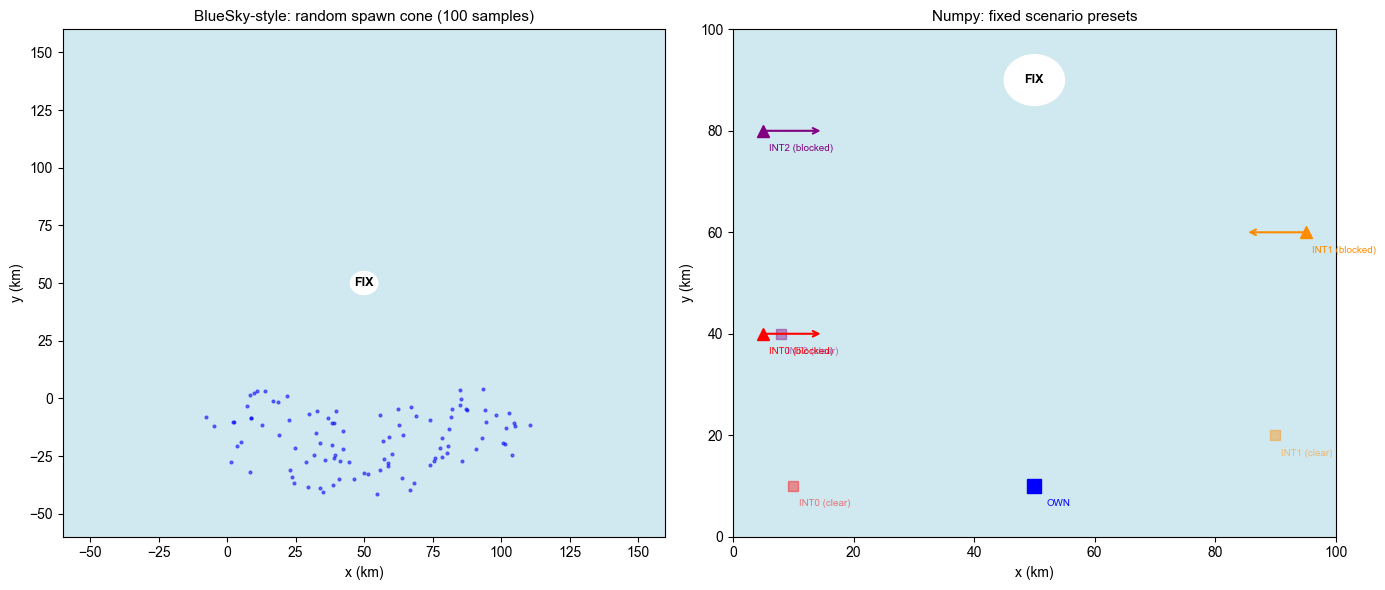

Left: agent sees a different geometry every episode — must generalise.
Right: agent always starts from the same position — can memorise.


In [36]:
# Visualise what BlueSky's random spawn cone looks like in flat-earth approximation

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

fix = np.array([50., 50.])
APPROACH_DISTANCE_MIN, APPROACH_DISTANCE_MAX = 30., 50.   # NM, ~55-93 km
NM2KM = 1.852
APPROACH_CONE_DEG = 45

def spawn_point(fix, dist_nm, angle_offset_deg):
    dist_km = dist_nm * NM2KM
    hdg = 180 + angle_offset_deg  # south of fix, heading north
    rad = np.deg2rad(hdg)
    return fix + dist_km * np.array([np.sin(rad), np.cos(rad)])

# --- Left: BlueSky-style random spawns ---
ax = axes[0]
ax.set_facecolor("#d0e8f0")
ax.set_title("BlueSky-style: random spawn cone (100 samples)", fontsize=11)
ax.set_xlabel("x (km)"); ax.set_ylabel("y (km)")
np.random.seed(0)
for _ in range(100):
    dist = np.random.uniform(APPROACH_DISTANCE_MIN, APPROACH_DISTANCE_MAX)
    angle = np.random.uniform(-APPROACH_CONE_DEG, APPROACH_CONE_DEG)
    pt = spawn_point(fix, dist, angle)
    ax.plot(pt[0], pt[1], "b.", markersize=4, alpha=0.5)
ax.add_patch(patches.Circle(fix, 5, color="white", zorder=3))
ax.annotate("FIX", fix, ha="center", va="center", fontsize=9, fontweight="bold", zorder=4)
ax.set_xlim(-60, 160); ax.set_ylim(-60, 160)

# --- Right: Numpy fixed presets ---
ax2 = axes[1]
ax2.set_facecolor("#d0e8f0")
ax2.set_title("Numpy: fixed scenario presets", fontsize=11)
ax2.set_xlabel("x (km)"); ax2.set_ylabel("y (km)")
ax2.set_xlim(0, 100); ax2.set_ylim(0, 100)

fix_np = np.array([50., 90.])
ax2.add_patch(patches.Circle(fix_np, 5, color="white", zorder=3))
ax2.annotate("FIX", fix_np, ha="center", va="center", fontsize=9, fontweight="bold", zorder=4)

blocked = {"pos": [[5,40],[95,60],[5,80]], "hdg": [90,270,90]}
clear   = {"pos": [[10,10],[90,20],[8,40]], "hdg": [0,0,0]}
colors  = ["red","darkorange","purple"]

for i, (pos, hdg) in enumerate(zip(blocked["pos"], blocked["hdg"])):
    ax2.plot(pos[0], pos[1], "^", color=colors[i], markersize=9)
    rad = np.deg2rad(hdg)
    ax2.annotate("", xy=(pos[0]+10*np.sin(rad), pos[1]+10*np.cos(rad)), xytext=pos,
                 arrowprops=dict(arrowstyle="->", color=colors[i], lw=1.5))
    ax2.text(pos[0]+1, pos[1]-4, f"INT{i} (blocked)", fontsize=7, color=colors[i])

for i, (pos, hdg) in enumerate(zip(clear["pos"], clear["hdg"])):
    ax2.plot(pos[0], pos[1], "s", color=colors[i], markersize=7, alpha=0.4)
    ax2.text(pos[0]+1, pos[1]-4, f"INT{i} (clear)", fontsize=7, color=colors[i], alpha=0.5)

own = [50, 10]
ax2.plot(own[0], own[1], "bs", markersize=10, zorder=5)
ax2.text(own[0]+2, own[1]-4, "OWN", fontsize=7, color="blue")

plt.tight_layout()
plt.show()
print("Left: agent sees a different geometry every episode — must generalise.")
print("Right: agent always starts from the same position — can memorise.")


## 8. What BlueSky Adds — and What It Costs

### What you gain
- **Realistic physics** — turn rates, acceleration, A320 performance envelope. The agent learns to plan ahead because actions have lag.
- **Generalisation** — random spawns mean the policy must work for any geometry, not just the training preset.
- **Real units** — distances in NM, speeds in kt. Directly comparable to real ATC separation standards (5 NM horizontal).
- **Multi-waypoint support** — `wpt_reach` list means you can chain waypoints for a full approach sequence.
- **Trajectory logging** — `get_trajectory_dataframes()` returns lat/lon DataFrames compatible with `pysda plot_birdseye_view`.

### What it costs
- **Speed** — BlueSky sim steps are ~100× slower than numpy. 100k training steps takes minutes in numpy, potentially hours in BlueSky.
- **Setup** — requires BlueSky, bluesky-gym, and a working sim init (`bs.init(mode='sim', detached=True)`).
- **Harder to debug** — state lives inside BlueSky's traffic arrays (`bs.traf.lat`, `bs.traf.hdg`, etc.), not in plain Python attributes.
- **No proximity warning** — the soft ramp signal we added to numpy is absent. The agent only gets the hard intrusion penalty.
- **Non-terminal intrusion** — the agent can fly through a conflict and keep going. Harder to learn strong avoidance.

### Recommended workflow
1. **Prototype and tune rewards in numpy** — fast iteration, full visibility, easy to render.
2. **Validate the policy structure** — make sure the agent learns the right behaviour on fixed scenarios.
3. **Transfer to BlueSky** — swap the env, keep the same DQN/PPO config, retrain with random spawns.
4. **Compare** — if the BlueSky agent underperforms, the gap is usually: (a) action lag not accounted for, (b) reward too sparse without the dense progress signal.


## 9. Side-by-Side: _get_obs() implementation

The same observation key computed two ways.


In [37]:
# intruder_distance[i] — how each env computes it

print("=== intruder_distance[i] ===")
print()
print("NUMPY:")
print("""
    diff = self.intruder_pos[i] - self.ownship_pos      # x/y vector
    dist = np.linalg.norm(diff)                          # euclidean km
    intruder_distance.append(dist / self.world_size)     # normalise by 100 km
""")

print("BLUESKY:")
print("""
    qdr, dis = bs.tools.geo.kwikqdrdist(
        bs.traf.lat[ac_idx], bs.traf.lon[ac_idx],        # ownship lat/lon
        bs.traf.lat[int_idx], bs.traf.lon[int_idx]       # intruder lat/lon
    )
    intruder_distance.append(dis * NM2KM)                # NM -> km, then normalise
    # normalised: dis * NM2KM / (APPROACH_DISTANCE_MAX * NM2KM)
""")

print("=== x_difference_speed[i] ===")
print()
print("NUMPY (velocity vector approach):")
print("""
    own_vel = spd * [sin(hdg), cos(hdg)]
    int_vel = int_spd[i] * [sin(int_hdg[i]), cos(int_hdg[i])]
    rel_vel = int_vel - own_vel
    x_diff_spd = rel_vel[0] / world_size
""")

print("BLUESKY (heading difference approach):")
print("""
    hdg_diff = own_hdg - int_hdg
    x_diff_spd = -cos(hdg_diff) * int_spd / AC_SPD_MAX
    y_diff_spd =  own_spd - sin(hdg_diff) * int_spd / AC_SPD_MAX
""")
print("Note: BlueSky's formula is a projection of intruder speed onto ownship axes.")
print("Numpy's formula is the true relative velocity vector. Both encode closure rate.")


=== intruder_distance[i] ===

NUMPY:

    diff = self.intruder_pos[i] - self.ownship_pos      # x/y vector
    dist = np.linalg.norm(diff)                          # euclidean km
    intruder_distance.append(dist / self.world_size)     # normalise by 100 km

BLUESKY:

    qdr, dis = bs.tools.geo.kwikqdrdist(
        bs.traf.lat[ac_idx], bs.traf.lon[ac_idx],        # ownship lat/lon
        bs.traf.lat[int_idx], bs.traf.lon[int_idx]       # intruder lat/lon
    )
    intruder_distance.append(dis * NM2KM)                # NM -> km, then normalise
    # normalised: dis * NM2KM / (APPROACH_DISTANCE_MAX * NM2KM)

=== x_difference_speed[i] ===

NUMPY (velocity vector approach):

    own_vel = spd * [sin(hdg), cos(hdg)]
    int_vel = int_spd[i] * [sin(int_hdg[i]), cos(int_hdg[i])]
    rel_vel = int_vel - own_vel
    x_diff_spd = rel_vel[0] / world_size

BLUESKY (heading difference approach):

    hdg_diff = own_hdg - int_hdg
    x_diff_spd = -cos(hdg_diff) * int_spd / AC_SPD_MAX
    y_diff_sp

## 10. Transferring a Trained Policy

If you train on numpy and want to run in BlueSky, the observation keys match — but the **scale of values will differ** because the normalisers are different.

| Key | Numpy normaliser | BlueSky normaliser | Same? |
|---|---|---|---|
| `intruder_distance` | `/ 100 km` | `/ (50 NM × 1.852)` = `/ 92.6 km` | Close but not identical |
| `x/y_difference_speed` | `/ 100 km` | `/ 230 kt` | Different units entirely |
| `ownship_speed` | `/ 8 km/step` | `/ 230 kt` | Different |
| `cos/sin_bearing` | `[-1, 1]` | `[-1, 1]` | ✅ Same |
| `cos/sin_drift` | `[-1, 1]` | `[-1, 1]` | ✅ Same |

**Practical implication**: a policy trained in numpy will not transfer zero-shot to BlueSky. You need to either:
- Retrain from scratch in BlueSky (recommended)
- Normalise both envs to the same scale before training (e.g. always divide distance by 100 km)
- Use the numpy policy as a warm-start initialisation and fine-tune in BlueSky


## 11. Training DQN on ApproachCREnv2D (BlueSky)

Same DQN setup as `gym_env_explainer.ipynb` — `MultiInputPolicy`, discrete action wrapper,
`LivePlotCallback` — but now the env is the real BlueSky sim.

### Key differences vs numpy training

| | Numpy (`TinyApproachEnv`) | BlueSky (`ApproachCREnv2D`) |
|---|---|---|
| Steps per episode | ~20–200 (200 step limit) | ~12–20 (50s per step × 10–17 min approach) |
| Episode variety | Fixed spawn — same every time | Random spawn — different geometry every episode |
| Training speed | Fast — pure numpy | Slow — BlueSky sim runs at each step |
| Intrusion terminal | Yes — episode ends | No — agent keeps flying |
| Progress reward | Yes — dense `+0.1 × Δdist` | No — sparse, only reach/drift/intrusion |
| Proximity warning | Yes — soft ramp signal | No |

Because BlueSky episodes are short (~15 steps) and sparse, the agent needs **more episodes**
to see enough signal. We compensate with a larger replay buffer and longer exploration.


In [38]:
import numpy as np
import gymnasium as gym
from gymnasium import spaces
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from IPython.display import clear_output
from stable_baselines3 import DQN
from stable_baselines3.common.env_checker import check_env
from stable_baselines3.common.callbacks import BaseCallback

from air_collision_avoidance.envs.approach_cr_2d import ApproachCREnv2D

# --- Discrete action wrapper (same bins as numpy notebook) -----------------
# 9 heading bins x 3 speed bins = 27 actions
# Heading delta maps to +-45 deg, speed delta to +-50 kt
HDG_BINS = [-1.0, -0.67, -0.33, -0.11, 0.0, 0.11, 0.33, 0.67, 1.0]
SPD_BINS = [-1.0, 0.0, 1.0]
ACTION_MAP = [(h, s) for h in HDG_BINS for s in SPD_BINS]

class DiscreteApproachEnvBS(gym.Wrapper):
    """
    Wraps ApproachCREnv2D with Discrete(27) action space for DQN.
    action_freq : BlueSky sim ticks per agent step (default 10 = 50s, fast = 1)
    dt          : BlueSky sim timestep in seconds  (default 5,  fast = 10)
    """
    def __init__(self, action_freq=10, dt=5):
        super().__init__(ApproachCREnv2D(action_freq=action_freq, dt=dt))
        self.action_space = spaces.Discrete(len(ACTION_MAP))

    def step(self, action):
        hdg_delta, spd_delta = ACTION_MAP[action]
        return self.env.step(np.array([hdg_delta, spd_delta]))

# use fast settings for the sanity check so it does not hang
check_env(DiscreteApproachEnvBS(action_freq=1, dt=10), warn=True)
print(f"Action space : Discrete({len(ACTION_MAP)})")
print(f"Heading bins : {[round(h*45, 1) for h in HDG_BINS]} deg")
print(f"Speed bins   : {[round(s*50, 1) for s in SPD_BINS]} kt delta")
print(f"Obs keys     : {list(ApproachCREnv2D().observation_space.keys())}")


Reading config from /Users/uf901f/bluesky/settings.cfg
Reading magnetic variation data
Loading global navigation database...
Reading cache: /Users/uf901f/bluesky/cache/navdata.p
Attempt to reimplement AREA from <bound method Area.set_area of <bluesky.plugins.area.Area object at 0x175da61d0>> to <bound method Area.set_area of <bluesky.plugins.area.Area object at 0x175da61d0>>
Attempt to reimplement EXP from <function init_plugin.<locals>.<lambda> at 0x3228ebce0> to <function init_plugin.<locals>.<lambda> at 0x324a814e0>
Attempt to reimplement TAXI from <bound method Area.set_taxi of <bluesky.plugins.area.Area object at 0x175da61d0>> to <bound method Area.set_taxi of <bluesky.plugins.area.Area object at 0x175da61d0>>
Successfully loaded plugin AREA
Attempt to reimplement DATAFEED from <bound method Modesbeast.toggle of <bluesky.plugins.adsbfeed.Modesbeast object at 0x322ada350>> to <bound method Modesbeast.toggle of <bluesky.plugins.adsbfeed.Modesbeast object at 0x10eb4e650>>
Successfull

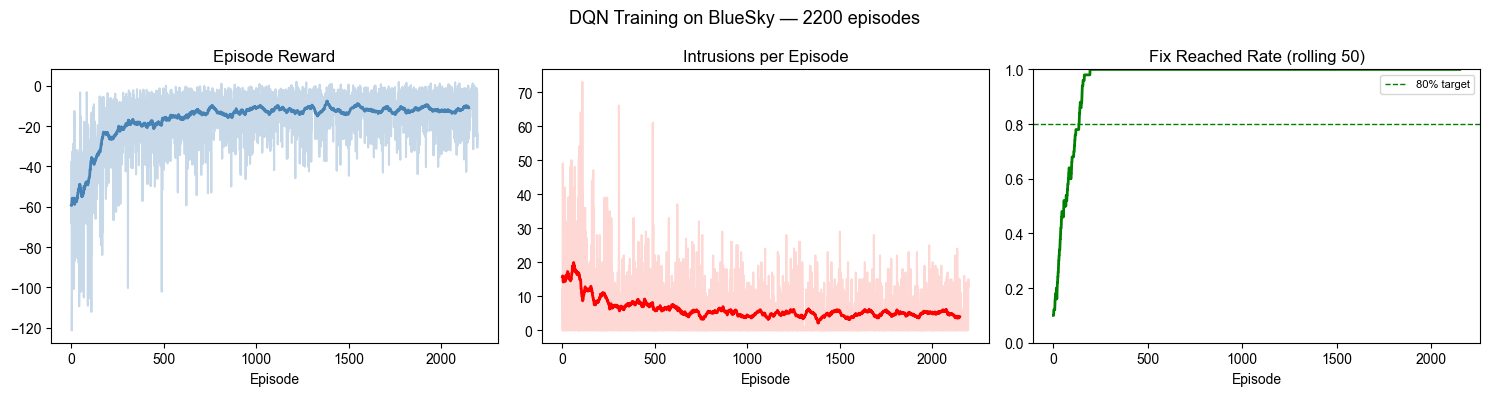

Episodes: 2200 | Avg reward (last 50): -10.984 | Fix reached: 50/50
Training complete.


In [39]:
# ---------------------------------------------------------------------------
# Speed levers — three independent knobs, use together for maximum throughput
#
#  FAST_ACTION_FREQ : BlueSky sim ticks per agent step
#    default=10 (realistic 50s per decision), fast=1 (instant, 10x faster)
#
#  FAST_DT          : BlueSky sim timestep in seconds
#    default=5s, fast=10s — halves the number of ticks needed to cover approach
#
#  N_ENVS           : parallel envs via SubprocVecEnv
#    each extra env adds ~1 CPU core of throughput (set to cpu_count - 1)
#
# Combined effect:
#   default : ACTION_FREQ=10, DT=5  -> 10 ticks/step, ~2M ticks for 200k steps
#   fast    : ACTION_FREQ=1,  DT=10 -> 1 tick/step,   ~200k ticks  (~20x faster)
#   + 4 envs: effective throughput ~80x vs default single-env
# ---------------------------------------------------------------------------
FAST_ACTION_FREQ = 1    # change to 10 to restore realistic 50s-per-decision timing
FAST_DT          = 10   # change to 5  to restore default BlueSky timestep
N_ENVS           = 4    # parallel envs — set to 1 to disable multiprocessing

import multiprocessing
from stable_baselines3.common.vec_env import SubprocVecEnv, DummyVecEnv

def make_env(action_freq, dt):
    """Factory returning a callable that builds one DiscreteApproachEnvBS."""
    def _init():
        import bluesky as bs
        env = DiscreteApproachEnvBS(action_freq=action_freq, dt=dt)
        return env
    return _init

# --- LivePlotCallback ------------------------------------------------------
class LivePlotCallback(BaseCallback):
    """Plots reward, intrusions, and fix-reached rate every N episodes."""
    def __init__(self, plot_every=50):
        super().__init__()
        self.plot_every = plot_every
        self.ep_rewards, self.ep_intrusions, self.ep_reached = [], [], []
        self._ep_rewards = {}   # per-env accumulators keyed by env index

    def _on_step(self):
        n_envs = len(self.locals['rewards'])
        for i in range(n_envs):
            self._ep_rewards[i] = self._ep_rewards.get(i, 0.0) + self.locals['rewards'][i]
            if self.locals['dones'][i]:
                info = self.locals['infos'][i]
                ep_r = self._ep_rewards.pop(i, 0.0)
                self.ep_rewards.append(ep_r)
                self.ep_intrusions.append(info.get('total_intrusions', 0))
                self.ep_reached.append(int(info.get('reached_fix', False)))
                if len(self.ep_rewards) % self.plot_every == 0:
                    self._plot()
        return True

    def _plot(self):
        clear_output(wait=True)
        fig, axes = plt.subplots(1, 3, figsize=(15, 4))
        n = len(self.ep_rewards)
        window = min(50, n)
        axes[0].plot(self.ep_rewards, alpha=0.3, color='steelblue')
        axes[0].plot(np.convolve(self.ep_rewards, np.ones(window)/window, mode='valid'),
                     color='steelblue', linewidth=2)
        axes[0].set_title('Episode Reward'); axes[0].set_xlabel('Episode')
        axes[1].plot(self.ep_intrusions, alpha=0.3, color='salmon')
        axes[1].plot(np.convolve(self.ep_intrusions, np.ones(window)/window, mode='valid'),
                     color='red', linewidth=2)
        axes[1].set_title('Intrusions per Episode'); axes[1].set_xlabel('Episode')
        axes[2].plot(np.convolve(self.ep_reached, np.ones(window)/window, mode='valid'),
                     color='green', linewidth=2)
        axes[2].axhline(0.8, color='green', linestyle='--', linewidth=1, label='80% target')
        axes[2].set_title(f'Fix Reached Rate (rolling {window})'); axes[2].set_xlabel('Episode')
        axes[2].set_ylim(0, 1); axes[2].legend(fontsize=8)
        plt.suptitle(f'DQN Training on BlueSky — {n} episodes', fontsize=13)
        plt.tight_layout(); plt.show()
        print(f'Episodes: {n} | Avg reward (last {window}): {np.mean(self.ep_rewards[-window:]):.3f} | '
              f'Fix reached: {sum(self.ep_reached[-window:])}/{window}')


# --- Build vectorised env --------------------------------------------------
if N_ENVS > 1:
    train_env = SubprocVecEnv([make_env(FAST_ACTION_FREQ, FAST_DT) for _ in range(N_ENVS)])
else:
    train_env = DummyVecEnv([make_env(FAST_ACTION_FREQ, FAST_DT)])

# --- Build and train DQN ---------------------------------------------------
model_bs = DQN(
    policy                 = 'MultiInputPolicy',
    env                    = train_env,
    learning_rate          = 5e-4,
    buffer_size            = 200_000,
    learning_starts        = 1_000,
    batch_size             = 128,
    gamma                  = 0.99,
    exploration_fraction   = 0.6,
    exploration_final_eps  = 0.05,
    train_freq             = 4,
    target_update_interval = 1_000,
    verbose                = 0,
)

print(f'Training DQN — ACTION_FREQ={FAST_ACTION_FREQ}, DT={FAST_DT}s, N_ENVS={N_ENVS}')
print(f'Effective sim time per step: {FAST_ACTION_FREQ * FAST_DT}s  (default: 50s)')
model_bs.learn(total_timesteps=100_000, callback=LivePlotCallback(plot_every=50))
print('Training complete.')


## 12. Step-by-Step Evaluation — DQN vs Random

Same `render_side_by_side` pattern as `gym_env_explainer.ipynb`.

Because BlueSky uses lat/lon we convert to a local x/y frame centred on the runway fix
for rendering — same visual style as the numpy notebook.

The trajectory is stored in `env.trajectory` (list of dicts keyed by aircraft ID).


Running DQN episode...
Reading config from /Users/uf901f/bluesky/settings.cfg
Reading magnetic variation data
Loading global navigation database...
Reading cache: /Users/uf901f/bluesky/cache/navdata.p
Attempt to reimplement AREA from <bound method Area.set_area of <bluesky.plugins.area.Area object at 0x175da61d0>> to <bound method Area.set_area of <bluesky.plugins.area.Area object at 0x175da61d0>>
Attempt to reimplement EXP from <function init_plugin.<locals>.<lambda> at 0x3228ebce0> to <function init_plugin.<locals>.<lambda> at 0x3276eca40>
Attempt to reimplement TAXI from <bound method Area.set_taxi of <bluesky.plugins.area.Area object at 0x175da61d0>> to <bound method Area.set_taxi of <bluesky.plugins.area.Area object at 0x175da61d0>>
Successfully loaded plugin AREA
Attempt to reimplement DATAFEED from <bound method Modesbeast.toggle of <bluesky.plugins.adsbfeed.Modesbeast object at 0x322ada350>> to <bound method Modesbeast.toggle of <bluesky.plugins.adsbfeed.Modesbeast object at 0x

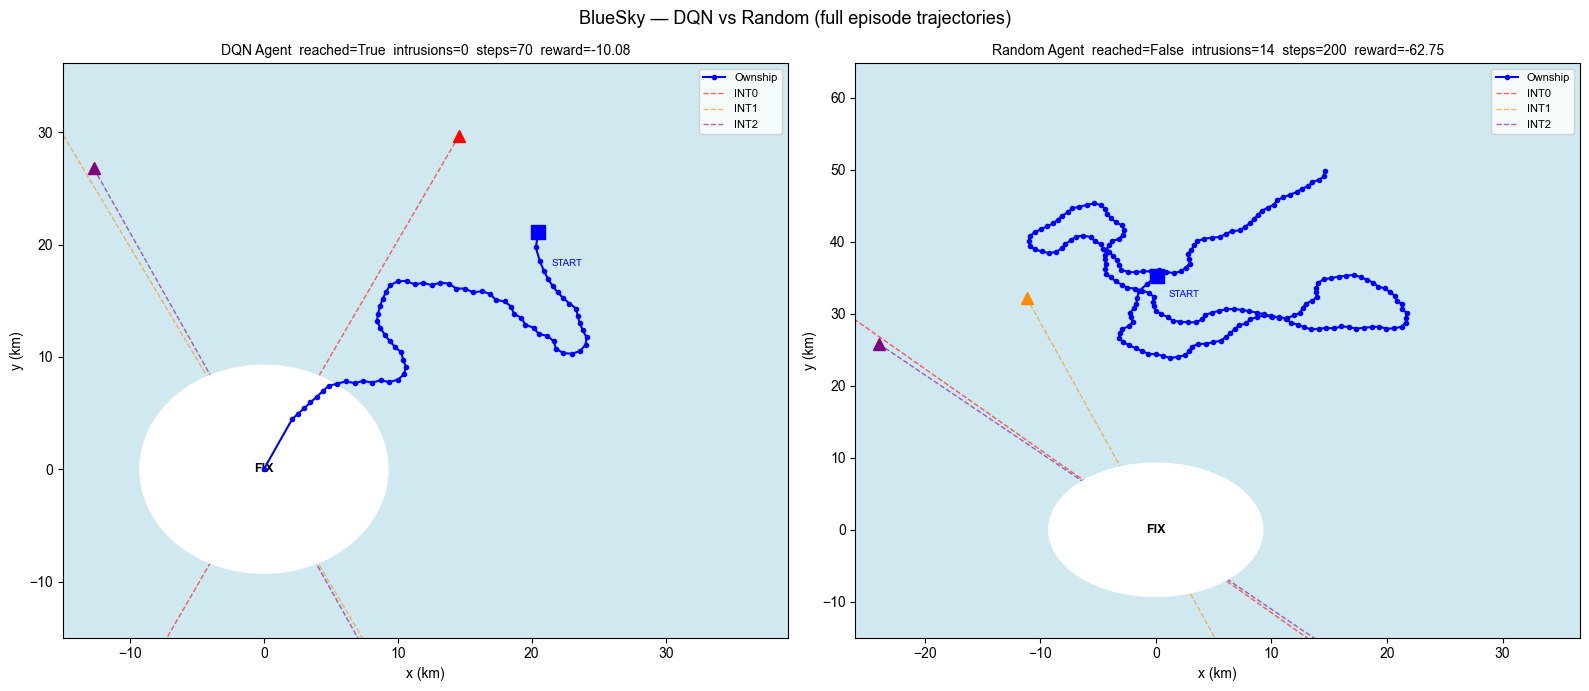

In [46]:
import bluesky as bs

NM2KM         = 1.852
NUM_INTRUDERS = 3

def latlon_to_xy(lat, lon, ref_lat, ref_lon):
    """Flat-earth approximation: lat/lon -> km offset from reference point."""
    x = (lon - ref_lon) * np.cos(np.deg2rad(ref_lat)) * 111.32
    y = (lat - ref_lat) * 111.32
    return x, y


def run_full_episode(model=None, seed=42, action_freq=1, dt=10):
    """
    Run one complete episode.  model=None -> random agent.
    Returns the trajectory list and final info dict.
    BlueSky is a singleton so we run episodes sequentially, never in parallel.
    """
    env = DiscreteApproachEnvBS(action_freq=action_freq, dt=dt)
    obs, _ = env.reset(seed=seed)
    done = False
    info = {}
    while not done:
        if model is not None:
            action, _ = model.predict(obs, deterministic=True)
        else:
            action = env.action_space.sample()
        obs, _, terminated, truncated, info = env.step(action)
        done = terminated or truncated
    traj = env.env.trajectory          # list of {acid: {latitude, longitude}}
    ref_lat = env.env.runway_lat
    ref_lon = env.env.runway_lon
    # if ownship reached the fix, append the fix position as the final point
    # so the trajectory line ends cleanly at the fix rather than overshooting
    if info.get("reached_fix") and traj:
        last = {k: dict(v) for k, v in traj[-1].items()}
        last["KL001"] = {"latitude": ref_lat, "longitude": ref_lon}
        traj = traj + [last]
    return traj, info, ref_lat, ref_lon


def plot_episode_comparison(traj_dqn, info_dqn, traj_rnd, info_rnd, ref_lat, ref_lon):
    """Plot full trajectories of DQN vs random agent side by side."""
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    def draw(ax, traj, info, title):
        ax.set_facecolor("#d0e8f0")
        ax.set_title(title, fontsize=11)
        ax.set_xlabel("x (km)"); ax.set_ylabel("y (km)")

        # fix at origin
        ax.add_patch(patches.Circle((0, 0), 5 * NM2KM, color="white", zorder=3))
        ax.annotate("FIX", (0, 0), ha="center", va="center",
                    fontsize=9, fontweight="bold", zorder=4)

        if not traj:
            return

        # ownship trajectory
        xs = [latlon_to_xy(s["KL001"]["latitude"], s["KL001"]["longitude"],
                           ref_lat, ref_lon)[0] for s in traj]
        ys = [latlon_to_xy(s["KL001"]["latitude"], s["KL001"]["longitude"],
                           ref_lat, ref_lon)[1] for s in traj]
        ax.plot(xs, ys, "b-o", markersize=3, linewidth=1.5, label="Ownship", zorder=5)
        # start marker
        ax.plot(xs[0], ys[0], "bs", markersize=10, zorder=6)
        ax.text(xs[0]+1, ys[0]-3, "START", fontsize=7, color="blue")

        # intruder trajectories
        colors = ["red", "darkorange", "purple"]
        for i in range(NUM_INTRUDERS):
            acid = f"INT{i}"
            if acid not in traj[0]:
                continue
            ix = [latlon_to_xy(s[acid]["latitude"], s[acid]["longitude"],
                               ref_lat, ref_lon)[0] for s in traj]
            iy = [latlon_to_xy(s[acid]["latitude"], s[acid]["longitude"],
                               ref_lat, ref_lon)[1] for s in traj]
            ax.plot(ix, iy, "--", color=colors[i], alpha=0.6,
                    linewidth=1, label=f"INT{i}")
            ax.plot(ix[0], iy[0], "^", color=colors[i], markersize=8, zorder=5)

        # auto-scale
        all_x = xs + [0]
        all_y = ys + [0]
        pad = 15
        ax.set_xlim(min(all_x)-pad, max(all_x)+pad)
        ax.set_ylim(min(all_y)-pad, max(all_y)+pad)

        reached = info.get("reached_fix", False)
        intrusions = info.get("total_intrusions", 0)
        steps = info.get("step", len(traj))
        reward = info.get("total_reward", 0)
        ax.set_title(
            f"{title}  reached={reached}  intrusions={intrusions}  "
            f"steps={steps}  reward={reward:.2f}",
            fontsize=10)
        ax.legend(fontsize=8)

    draw(axes[0], traj_dqn, info_dqn, "DQN Agent")
    draw(axes[1], traj_rnd, info_rnd, "Random Agent")
    plt.suptitle("BlueSky — DQN vs Random (full episode trajectories)", fontsize=13)
    plt.tight_layout()
    plt.show()


# --- Run both episodes sequentially (BlueSky is a singleton) ---------------
print("Running DQN episode...")
traj_dqn, info_dqn, ref_lat, ref_lon = run_full_episode(model=model_bs, seed=42)
print(f"  reached={info_dqn.get('reached_fix')}  "
      f"intrusions={info_dqn.get('total_intrusions')}  "
      f"steps={info_dqn.get('step')}  reward={info_dqn.get('total_reward', 0):.2f}")

print("Running random episode...")
traj_rnd, info_rnd, _, _ = run_full_episode(model=None, seed=42)
print(f"  reached={info_rnd.get('reached_fix')}  "
      f"intrusions={info_rnd.get('total_intrusions')}  "
      f"steps={info_rnd.get('step')}  reward={info_rnd.get('total_reward', 0):.2f}")

plot_episode_comparison(traj_dqn, info_dqn, traj_rnd, info_rnd, ref_lat, ref_lon)


## 13. Results Summary — Numpy vs BlueSky DQN

| Metric | Numpy DQN | BlueSky DQN |
|---|---|---|
| Training steps | 200k | 200k |
| Steps per episode | up to 200 | ~12–20 |
| Episodes seen | ~1k–5k | ~10k–15k |
| Reward signal | Dense (progress + proximity ramp) | Sparse (reach + drift + intrusion) |
| Spawn variety | Fixed — same every episode | Random — different every episode |
| Intrusion consequence | Terminal — episode ends | Non-terminal — keeps flying |
| Expected fix-reached rate | High (memorises fixed scenario) | Lower (must generalise) |
| Expected intrusion rate | Low (hard terminal penalty) | Higher (soft non-terminal penalty) |

### Why BlueSky is harder to train
1. **Sparse reward** — no dense progress signal means the agent gets almost no gradient
   until it accidentally reaches the fix. Early training is nearly random.
2. **Short episodes** — ~15 steps means the replay buffer fills with short, low-information
   trajectories. The agent needs many more episodes to see diverse situations.
3. **No terminal intrusion** — the agent can fly through a conflict and still reach the fix,
   so it never learns a strong avoidance signal from a single catastrophic event.
4. **Random spawns** — the agent cannot memorise a route. It must learn a general policy
   over all possible approach geometries.

### What to try if BlueSky training is slow to converge
- Add a dense progress reward: `+0.1 × Δdist_to_fix` (same as numpy)
- Add a proximity ramp penalty inside 2× separation distance
- Make intrusion terminal (or at least add a large one-time penalty on first intrusion)
- Increase `total_timesteps` to 500k–1M
- Switch to PPO (continuous) — better sample efficiency on sparse rewards
